# Chapter 3 — k-point convergence: metal vs. semiconductor

Companion notebook to Chapter 3. We compare how the total energy
converges with the Monkhorst–Pack grid density for an **insulator**
(GaAs, fixed occupations) and a **metal** (fcc Al, with smearing). The
contrast is the whole point of the chapter. Requirements: `numpy`,
`matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

RY_TO_MEV = 13605.693
d = Path('../code/03-brillouin-zone')
ng, Eg = np.loadtxt(d/'gaas_kconv.dat', skiprows=1, unpack=True)   # 2 atoms
na, Ea = np.loadtxt(d/'al_kconv.dat', skiprows=1, unpack=True)     # 1 atom

dEg = np.abs(Eg - Eg[-1]) / 2 * RY_TO_MEV   # GaAs: per atom
dEa = np.abs(Ea - Ea[-1]) / 1 * RY_TO_MEV   # Al: per atom

print('GaAs:  N  |E-E_ref| meV/atom')
for n, y in zip(ng, dEg): print(f'      {int(n):2d}   {y:8.2f}')
print('\nAl:    N  |E-E_ref| meV/atom')
for n, y in zip(na, dEa): print(f'      {int(n):2d}   {y:8.2f}')

GaAs:  N  |E-E_ref| meV/atom
       2    1226.38
       4      90.20
       6      12.56
       8       2.38
      10       0.46
      12       0.00

Al:    N  |E-E_ref| meV/atom
       2     660.92
       4     295.82
       6      69.69
       8       4.16
      10      16.09
      12       6.28
      16       4.98
      20       0.00


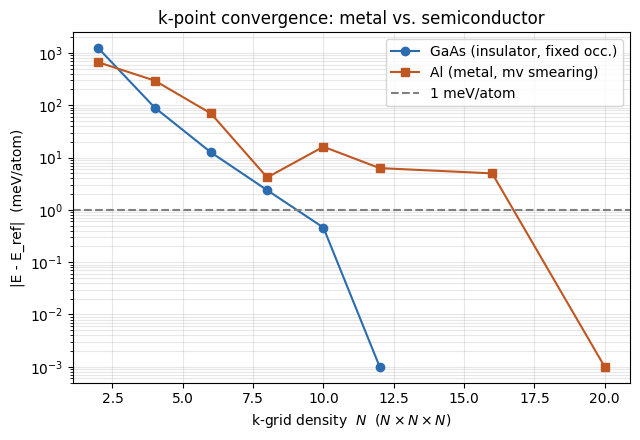

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.semilogy(ng, np.maximum(dEg, 1e-3), 'o-', color='#2b6cb0', label='GaAs (insulator, fixed occ.)')
ax.semilogy(na, np.maximum(dEa, 1e-3), 's-', color='#c05621', label='Al (metal, mv smearing)')
ax.axhline(1.0, ls='--', color='gray', label='1 meV/atom')
ax.set_xlabel(r'k-grid density  $N$  ($N\times N\times N$)')
ax.set_ylabel('|E - E_ref|  (meV/atom)')
ax.set_title('k-point convergence: metal vs. semiconductor')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
out_png = Path('../static/img/03-kpoint-convergence.png')
fig.savefig(out_png, dpi=120)
plt.show()

**What you see.** GaAs (insulator) converges fast and smoothly: a
modest grid already nails the energy, because the occupied states fill
complete bands and the integrand is smooth across the Brillouin zone.
Aluminium (metal) converges **slowly and non-monotonically**: the
partially-filled band has a Fermi surface, so the occupation jumps from 1
to 0 somewhere inside the BZ, and the k-sum only resolves that surface
with a dense grid — even *with* smearing to soften the step. Metals need
denser k-grids than insulators, full stop.